Team Members: Rachel Schultz, Nefeli Zafeiri, Nicole Niewiadomski, MJ Fiscina

# Models + Best Model
- ARIMA (1, 1, 1)
- ARIMAX(1, 1, 1) with four external regressors: layoffs, quits, sales, and wages
- Naive Forecast
- 12 Month Moving Average (Best Model)
- Hybrid (OLS + ARIMA on Residuals)

## Summary

We compared several models to determine which best captured the structure of the data and produced the most reliable predictions. We began with a Naive forecast as a benchmark, which assumes the next value equals the most recent observation. While useful as a baseline, it did not account for trend or seasonality. We then tested a 12-Month Moving Average, which smooths short-term fluctuations and better captures longer-term patterns. This model produced the lowest MAPE and the most stable forecasts overall, making it our best-performing model.

Next, we estimated an ARIMA (1, 1, 1). ARIMA improved upon the Naive model by capturing time dependence, but its forecast errors were still higher than the moving average in our case. We then extended this to an ARIMAX (1, 1, 1) model with four external regressors: layoffs, quits, sales, and wages. The idea was that adding relevant economic indicators would improve predictive power. While the regressors added interpretability and some explanatory insight, the accuracy gains were limited relative to the added complexity.

Finally, we tested a Hybrid model combining OLS with ARIMA on the residuals. This approach first modeled the structural relationships using regression and then captured remaining autocorrelation with ARIMA. Although, it did not outperform the 12-month moving average in terms of MAPE and stability.

Overall, while ARIMA, ARIMAX, and the Hybrid model were more complex, the 12-Month Moving Average had the best balance of accuracy, stability, and simplicity. Therefore, we selected it as the final model.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.deterministic import DeterministicProcess


# Delete some of these
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import VAR # Vector Autoregression
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import boxcox_normmax
from statsmodels.stats.diagnostic import acorr_ljungbox

# Exponential Smoothing (ETS) Models:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

!pip install pmdarima

In [ ]:
def acf_plots(y, lags=20, pacf_method="ywm"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    y = y.dropna()
    plot_acf(y, lags=lags, ax=axes[0])
    plot_pacf(y, lags=lags,  method=pacf_method, ax=axes[1])
    axes[0].set_title("ACF")
    axes[1].set_title("PACF")
    axes[0].set_xlim((0, lags))
    axes[1].set_xlim((0, lags))
    plt.tight_layout()
    return fig.show()

In [ ]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import acf

def eacf_plot(y, max_p=4, max_q=4):
    y = y.dropna()
    y = np.asarray(y)
    n = len(y)
    crit = 2 / np.sqrt(n)  # approx 95% CI

    table = np.empty((max_p + 1, max_q + 1), dtype=object)

    for p in range(max_p + 1):
        if p == 0:
            resid = y - y.mean()
        else:
            ar = AutoReg(y, lags=p, old_names=False).fit()
            resid = ar.resid

        r = acf(resid, nlags=max_q, fft=False)

        for q in range(max_q + 1):
            table[p, q] = "o" if abs(r[q]) < crit else "x"

    return table

In [ ]:
df = pd.read_csv('train.csv')

In [ ]:
df.head()

,date,jobs,layoffs,quits,sales,wages
0,1/1/16,2877,2339,281,359013,22.51
1,2/1/16,2518,1470,258,362439,22.57
2,3/1/16,2653,1503,254,424203,22.48
3,4/1/16,3460,1597,326,408902,22.53
4,5/1/16,3043,1609,345,408799,22.60


In [ ]:
df['date']= pd.to_datetime(df['date'])

df= df.set_index('date')

y= df['jobs'].asfreq('MS')

/tmp/ipython-input-551/3545607022.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date']= pd.to_datetime(df['date'])


# ARIMA MODEL
ARIMA(1,1,1)

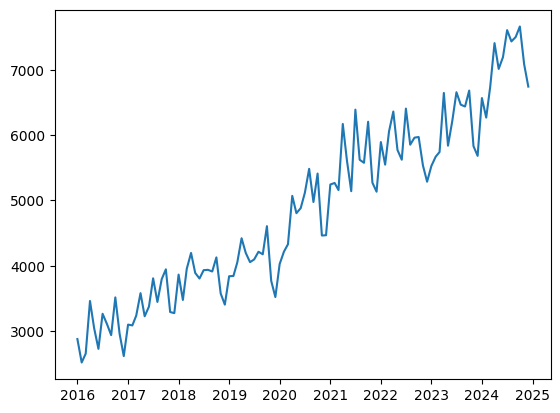

In [ ]:
plt.plot(y)

In [ ]:
ydiff = y.diff().dropna()

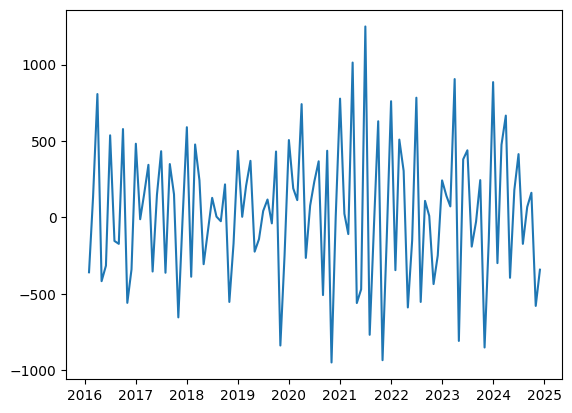

In [ ]:
plt.plot(ydiff)

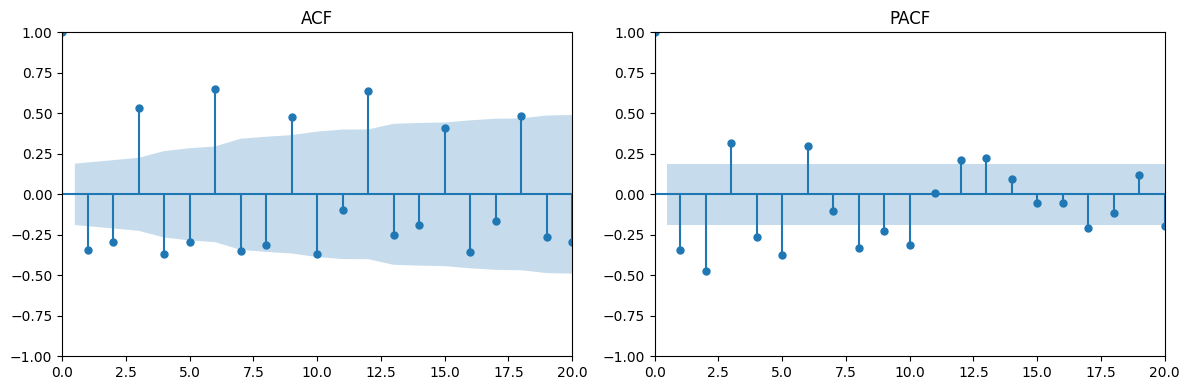

In [ ]:
acf_plots(ydiff)

In [ ]:
model = sm.tsa.ARIMA(y, order=(1,1,1))
results = model.fit()
print(results.summary())




                               SARIMAX Results                                
Dep. Variable:                   jobs   No. Observations:                  108
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -794.693
Date:                Sat, 28 Feb 2026   AIC                           1595.386
Time:                        18:47:28   BIC                           1603.405
Sample:                    01-01-2016   HQIC                          1598.637
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0777      0.202      0.385      0.700      -0.318       0.473
ma.L1         -0.5781      0.176     -3.290      0.001      -0.922      -0.234
sigma2      1.647e+05   2.41e+04      6.839      0.0

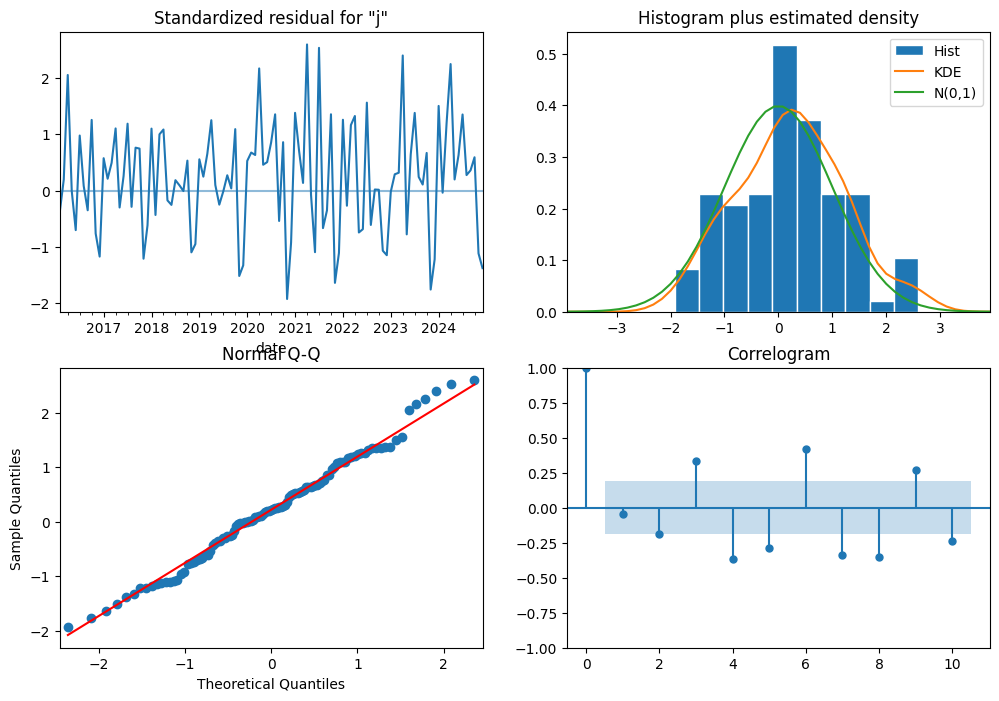

In [ ]:
results.plot_diagnostics(figsize=(12, 8))
plt.show()

In [ ]:
forecast = results.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean


forecast_df = pd.DataFrame({
    "date": range(1, 13),
    "jobs": forecast_mean.values
})
forecast_df.to_csv("12_month_forecast.csv", index=False)


forecast_df.head()





,date,jobs
0,1,7040.378742
1,2,7063.420102
2,3,7065.211406
3,4,7065.350667
4,5,7065.361494


In [ ]:
from google.colab import files
files.download("12_month_forecast.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **ARIMAX**

In [ ]:
y = df['jobs']

x = df[['layoffs', 'quits', 'sales', 'wages']]

In [ ]:
model = sm.tsa.ARIMA(y, order=(1,1,1), exog=x)
results = model.fit()

print(results.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   jobs   No. Observations:                  108
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -778.260
Date:                Sat, 28 Feb 2026   AIC                           1570.520
Time:                        18:47:32   BIC                           1589.230
Sample:                    01-01-2016   HQIC                          1578.105
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
layoffs       -0.4032      0.233     -1.731      0.083      -0.860       0.053
quits          4.5170      0.994      4.543      0.000       2.568       6.466
sales         -0.0002      0.002     -0.114      0.9

In [ ]:
future_x = pd.DataFrame(
    [x.iloc[-1].values] * 12,
    columns=x.columns
)


In [ ]:
forecast = results.get_forecast(steps=12, exog=future_x)
forecast_mean = forecast.predicted_mean


In [ ]:
forecast_df = pd.DataFrame({
    "date": range(1, 13),
    "jobs": forecast_mean.values
})

forecast_df.to_csv("12_month_forecast_arimax.csv", index=False)
files.download("12_month_forecast_arimax.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Moving Average Forecast

Best Model: 12 Month-Moving Average

In [ ]:
ma_12 = y.rolling(window=12).mean()
last_ma = ma_12.iloc[-1]
ma_forecast = [last_ma] * 12
ma_df = pd.DataFrame({
    "date": range(1, 13),
    "jobs": ma_forecast
})

ma_df.to_csv("12_month_moving_average_forecast.csv", index=False)
files.download("12_month_moving_average_forecast.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
last_value = y.iloc[-1]
naive_forecast = [last_value] * 12
naive_df = pd.DataFrame({
    "date": range(1, 13),
    "jobs": naive_forecast
})

naive_df.to_csv("12_month_naive_forecast.csv", index=False)
files.download("12_month_naive_forecast.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Found which variables are highly correlated and built an ARIMAX with only those variables

In [ ]:
df[['jobs', 'layoffs', 'quits', 'sales', 'wages']].corr()

,jobs,layoffs,quits,sales,wages
jobs,1.000000,-0.049150,0.831203,0.372038,0.948861
layoffs,-0.049150,1.000000,0.170625,-0.133027,-0.046895
quits,0.831203,0.170625,1.000000,0.394104,0.740866
sales,0.372038,-0.133027,0.394104,1.000000,0.317387
wages,0.948861,-0.046895,0.740866,0.317387,1.000000


In [ ]:
y = df['jobs']
X = df[['wages', 'quits']]


model = sm.tsa.ARIMA(y, order=(1,1,1), exog=X)
results = model.fit()

future_X = pd.DataFrame(
    [X.iloc[-1].values] * 12,
    columns=X.columns
)

forecast = results.get_forecast(steps=12, exog=future_X)
forecast_mean = forecast.predicted_mean
forecast_df = pd.DataFrame({
    "date": range(1, 13),
    "jobs": forecast_mean.values
})

forecast_df.to_csv("12_month_arimax_wages_quits.csv", index=False)

files.download("12_month_arimax_wages_quits.csv")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Hybrid

In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

X = df[['wages', 'quits']]
X = sm.add_constant(X)
y = df['jobs']

reg = sm.OLS(y, X).fit()


residuals = reg.resid
residuals = residuals.dropna()
residuals.index = pd.RangeIndex(len(residuals))
res_model = sm.tsa.ARIMA(residuals, order=(1,1,1)).fit()


future_X = pd.DataFrame(
    [df[['wages', 'quits']].iloc[-1].values] * 12,
    columns=['wages', 'quits']
)

future_X = sm.add_constant(future_X, has_constant='add')


reg_forecast = reg.predict(future_X)
reg_forecast = np.array(reg_forecast).reshape(12)




final_forecast = reg_forecast
forecast_df = pd.DataFrame({
    "date": range(1, 13),
    "jobs": final_forecast
})

In [ ]:
forecast_df.to_csv("hybrid.csv", index=False)

files.download("hybrid.csv")